# Data Splitting & Cross-Validation

* [Random split](#scrollTo=JFCrcH-MdxL5)
* [Stratified split](#scrollTo=FzX_o-23d0LH)
* [SMOTE](#scrollTo=COCyr9wbeUDR)
* [Time-based split](#scrollTo=Xabtutjod3tD)
* [Hierarchical split](#scrollTo=XhSxZG1od8sQ)
* [KFold CV](#scrollTo=GaIYbwKLeD_J)
* [Leave-One-Out Cross-Validation (LOOCV)](#scrollTo=OZqq9shhhjgW)
* [Bias - Variance](#scrollTo=ULd6dA9KeK8z)

# Import Libraries and Load Real Datasets

In [29]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import numpy as np
import pandas as pd
import requests
import zipfile
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GroupShuffleSplit, KFold, cross_val_score, TimeSeriesSplit
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from pathlib import Path

# Load Iris dataset for illustration (Balanced dataset)
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target, name='target')

import seaborn as sns
ames_data = sns.load_dataset('diamonds')  # Using 'diamonds' dataset for real data demonstration (similar in structure)

In [31]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/AirQuality/') # replace with your path to the dataset!
dataset_path = data_path/'AirQualityUCI.csv'


# Get the dataset
air_quality = pd.read_csv(dataset_path, sep=';', decimal=',', na_values=-200)
air_quality['Datetime'] = pd.to_datetime(air_quality['Date'] + ' ' + air_quality['Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')
air_quality = air_quality.drop(columns=['Date', 'Time']).dropna(subset=['Datetime'])
air_quality = air_quality.drop(columns=['Unnamed: 15', 'Unnamed: 16'])

air_quality = air_quality.dropna(subset=['CO(GT)', 'PT08.S1(CO)'], how='any')
air_quality = air_quality.fillna(-200)

# Filling or removing rows with too many missing values
threshold = len(air_quality.columns) * 0.5  # Allow rows with less than 50% missing data
air_quality = air_quality.dropna(thresh=threshold)

# Display the cleaned dataset
display(air_quality.head(10))
air_quality.shape

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00
5,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848,2004-03-10 23:00:00
6,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603,2004-03-11 00:00:00
7,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702,2004-03-11 01:00:00
8,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648,2004-03-11 02:00:00
9,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517,2004-03-11 03:00:00


(7344, 14)

In [32]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Diabetes Health Indicators Dataset/') # replace with your path to the dataset!
dataset_path = data_path/'diabetes_012_health_indicators_BRFSS2015.csv'


# Get the dataset
diabetes = pd.read_csv(dataset_path)
display(diabetes.head())
diabetes['Diabetes_012'].value_counts(normalize=True)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


,proportion
Diabetes_012,
0.0,0.842412
2.0,0.139333
1.0,0.018255


In [33]:
# Load Iris dataset for illustration (Balanced dataset)
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target, name='target')

In [34]:
# Load Ames Housing dataset (using seaborn for demonstration)
import seaborn as sns
ames_data = sns.load_dataset('diamonds')  # Using 'diamonds' dataset for real data demonstration (similar in structure)




---



In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


# Random split

Random Split - Good Example Accuracy: 0.97


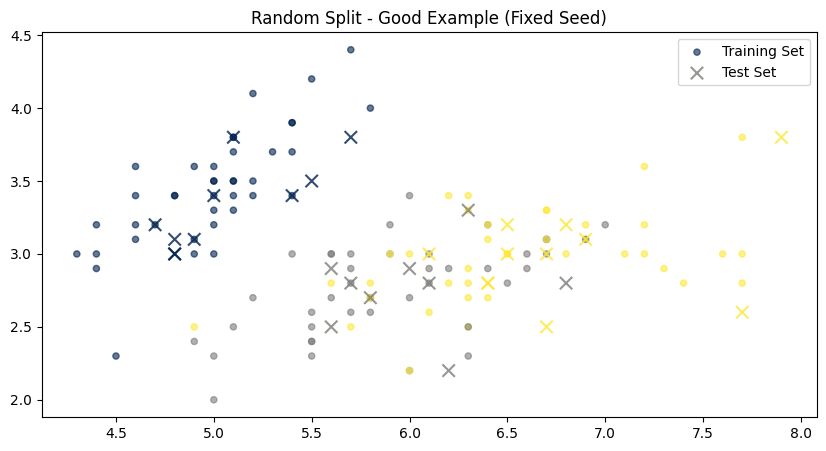

In [36]:
# DO: Random Split with fixed seed
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Fit a simple model
model = DecisionTreeClassifier(max_depth=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Split - Good Example Accuracy: {accuracy:.2f}")

# Plot the data split
plt.figure(figsize=(10, 5))
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, s=20., cmap='cividis', alpha=0.6, marker='o', label='Training Set')
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, s=80., cmap='cividis', alpha=0.8, marker='x', label='Test Set')
plt.title('Random Split - Good Example (Fixed Seed)')
plt.legend()
plt.show()

Random Split - Good Example Accuracy: 0.90


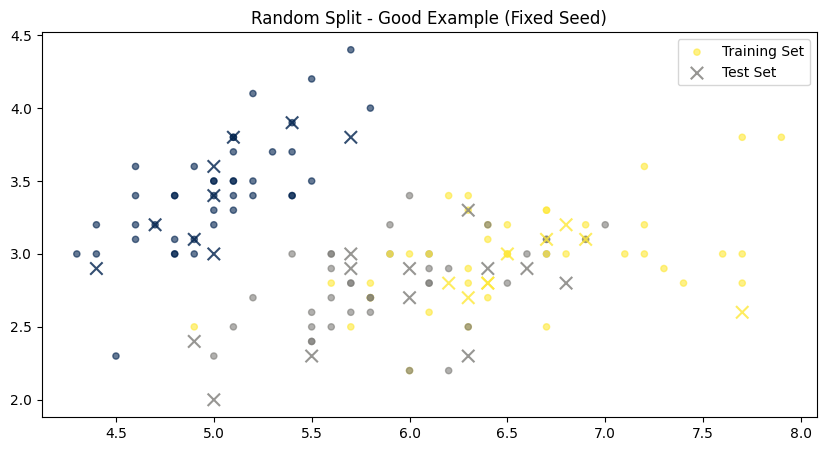

In [40]:
# DON'T: Random Split without fixed seed
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2)

# Fit a simple model
model = DecisionTreeClassifier(max_depth=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Split - Good Example Accuracy: {accuracy:.2f}")

# Plot the data split
plt.figure(figsize=(10, 5))
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, s=20., cmap='cividis', alpha=0.6, marker='o', label='Training Set')
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, s=80., cmap='cividis', alpha=0.8, marker='x', label='Test Set')
plt.title('Random Split - Good Example (Fixed Seed)')
plt.legend()
plt.show()


# Stratified split

In [41]:
from sklearn.datasets import fetch_openml
imbalanced = fetch_openml("Credit_Card_Fraud_")
print(imbalanced.DESCR)

imbalanced = imbalanced.frame

**Dataset Name**: card_transdata.csv

**Description**:
This dataset captures transaction patterns and behaviors that could indicate potential fraud in card transactions. The data is composed of several features designed to reflect the transactional context such as geographical location, transaction medium, and spending behavior relative to the user's history.

**Attribute Description**:
1. **distance_from_home**: This is a numerical feature representing the geographical distance in kilometers between the transaction location and the cardholder's home address.
2. **distance_from_last_transaction**: This numerical attribute measures the distance in kilometers from the location of the last transaction to the current transaction location.
3. **ratio_to_median_purchase_price**: A numeric ratio that compares the transaction's price to the median purchase price of the user's transaction history.
4. **repeat_retailer**: A binary attribute where '1' signifies that the transaction was conducted 

In [42]:
imbalanced.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [43]:
pd.Series(imbalanced['fraud']).value_counts(normalize=True)

,proportion
fraud,
0.0,0.912597
1.0,0.087403


In [44]:
 a = imbalanced.sample(frac=0.01, random_state=42)

In [45]:
# DO: Stratified Split

# Create a dataset with imbalanced classes
X, y = a, a['fraud']
X = X.drop(columns=['fraud'])
# make dataset even mode imbalanced = make 50% of 1s zeros

# get numeric features
numeric_features = X.select_dtypes(include=['number']).columns
print(y.value_counts(normalize=True))

# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=17)

# scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

# Fit a simple model
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(y_test.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Stratified Split -: Acc: {accuracy:.2f}, Pr: {precision:2f}, Rc: {recall:2f}, f1: {f1:2f}")


fraud
0.0    0.917
1.0    0.083
Name: proportion, dtype: float64
fraud
0.0    0.917
1.0    0.083
Name: proportion, dtype: float64
fraud
0.0    0.917
1.0    0.083
Name: proportion, dtype: float64
Stratified Split -: Acc: 0.96, Pr: 0.869565, Rc: 0.562249, f1: 0.682927


In [46]:
# Create a dataset with imbalanced classes
X, y = a, a['fraud']
X = X.drop(columns=['fraud'])

numeric_features = X.select_dtypes(include=['number']).columns
print(y.value_counts(normalize=True))

# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    stratify=None,
                                                    shuffle=True,
                                                    random_state=17)

# scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

# Fit a simple model
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(y_test.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Not Stratified Split -: Acc: {accuracy:.2f}, Pr: {precision:2f}, Rc: {recall:2f}, f1: {f1:2f}")


fraud
0.0    0.917
1.0    0.083
Name: proportion, dtype: float64
fraud
0.0    0.907333
1.0    0.092667
Name: proportion, dtype: float64
fraud
0.0    0.921143
1.0    0.078857
Name: proportion, dtype: float64
Not Stratified Split -: Acc: 0.95, Pr: 0.869048, Rc: 0.525180, f1: 0.654709


In [47]:
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Taiwanese Bankruptcy/') # replace with your path to the dataset!
dataset_path = data_path/'data.csv'


# Get the dataset
bancruptcy = pd.read_csv(dataset_path)
display(bancruptcy.head())
print(bancruptcy.shape)
bancruptcy['Bankrupt?'].value_counts(normalize=True)

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


(6819, 96)


,proportion
Bankrupt?,
0,0.967737
1,0.032263


In [48]:
# DO: Stratified Split
target_name = 'Bankrupt?'
a = bancruptcy.copy()
# Create a dataset with imbalanced classes
X, y = a, a[target_name]
X = X.drop(columns=[target_name])
# make dataset even mode imbalanced = make 50% of 1s zeros

# get numeric features
numeric_features = X.select_dtypes(include=['number']).columns
print(y.value_counts(normalize=True))

# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=17)

# scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

# Fit a simple model
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(y_test.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Stratified Split -: Acc: {accuracy:.2f}, Pr: {precision:2f}, Rc: {recall:2f}, f1: {f1:2f}")

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64
Bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64
Bankrupt?
0    0.967735
1    0.032265
Name: proportion, dtype: float64
Stratified Split -: Acc: 0.97, Pr: 0.531250, Rc: 0.257576, f1: 0.346939


In [49]:
# DON'T: not Stratified Split
target_name = 'Bankrupt?'
a = bancruptcy.copy()
# Create a dataset with imbalanced classes
X, y = a, a[target_name]
X = X.drop(columns=[target_name])
# make dataset even mode imbalanced = make 50% of 1s zeros

# get numeric features
numeric_features = X.select_dtypes(include=['number']).columns
print(y.value_counts(normalize=True))

# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    #stratify=y,
                                                    random_state=17)

# scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

# Fit a simple model
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(y_test.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Stratified Split -: Acc: {accuracy:.2f}, Pr: {precision:2f}, Rc: {recall:2f}, f1: {f1:2f}")

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64
Bankrupt?
0    0.969208
1    0.030792
Name: proportion, dtype: float64
Bankrupt?
0    0.967107
1    0.032893
Name: proportion, dtype: float64
Stratified Split -: Acc: 0.97, Pr: 0.500000, Rc: 0.206349, f1: 0.292135


# SMOTE

Please review! https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html

In [51]:
# Good Example: SMOTE applied on Training Set Only
smote = SMOTE(random_state=42)
a = bancruptcy.copy()
target_name = 'Bankrupt?'
X, y = a, a[target_name]
X = X.drop(columns=[target_name])
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=17)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)


# Fit a simple model
model = LogisticRegression(max_iter=200)
model.fit(X_resampled, y_resampled)
y_pred = model.predict(X_test_scaled)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Stratified Split -: Acc: {accuracy:.2f}, Pr: {precision:2f}, Rc: {recall:2f}, f1: {f1:2f}")


Stratified Split -: Acc: 0.89, Pr: 0.194030, Rc: 0.787879, f1: 0.311377


## SMOTE

### for Balancing Data

class distribution Counter({0: 9900, 1: 100})
new class distribution Counter({0: 1980, 1: 990})


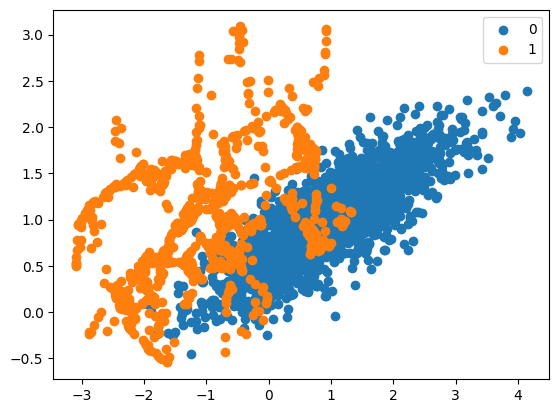

In [52]:
# Oversample with SMOTE and random undersample for imbalanced dataset
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from matplotlib import pyplot
from numpy import where

# define dataset
X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
 n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)

# summarize class distribution
counter = Counter(y)
print('class distribution',counter)

# define pipeline
over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)
steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)

# transform the dataset
X, y = pipeline.fit_resample(X, y)

# summarize the new class distribution
counter = Counter(y)
print('new class distribution', counter)

# scatter plot of examples by class label
for label, _ in counter.items():
 row_ix = where(y == label)[0]
 pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
pyplot.legend()
pyplot.show()

### SMOTE oversampling for imbalanced classification

In [53]:
from numpy import mean
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# define dataset
X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
 n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)

# values to evaluate
k_values = [1, 2, 3, 4, 5, 6, 7]

for k in k_values:
 # define pipeline
 model = DecisionTreeClassifier()
 over = SMOTE(sampling_strategy=0.1, k_neighbors=k)
 under = RandomUnderSampler(sampling_strategy=0.5)
 steps = [('over', over), ('under', under), ('model', model)]
 pipeline = Pipeline(steps=steps)

 # evaluate pipeline
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
 score = mean(scores)
 print('> k=%d, Mean ROC AUC: %.3f' % (k, score))

> k=1, Mean ROC AUC: 0.827
> k=2, Mean ROC AUC: 0.834
> k=3, Mean ROC AUC: 0.837
> k=4, Mean ROC AUC: 0.831
> k=5, Mean ROC AUC: 0.849
> k=6, Mean ROC AUC: 0.842
> k=7, Mean ROC AUC: 0.847


# Time-based split

Time-Based Split - Good Example Mean Squared Error: 0.52


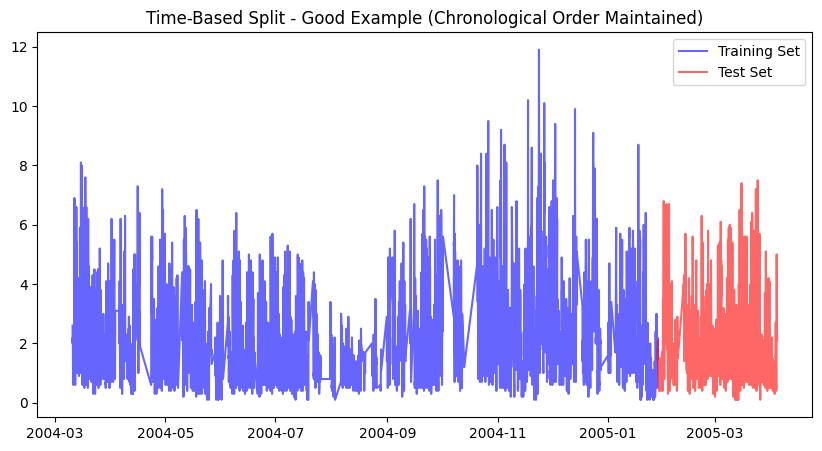

In [54]:
a = air_quality.copy()
a = a.fillna(-200)
train_size = int(len(a) * 0.8)
train_data = a[:train_size]
test_data = a[train_size:]

# Fit a simple model (Linear Regression on CO_GT)
model = LinearRegression()
model.fit(train_data[['PT08.S1(CO)']], train_data['CO(GT)'])
y_pred = model.predict(test_data[['PT08.S1(CO)']])

# Evaluate performance
mse = mean_squared_error(test_data['CO(GT)'], y_pred)
print(f"Time-Based Split - Good Example Mean Squared Error: {mse:.2f}")

# Plot the time-based data split
plt.figure(figsize=(10, 5))
plt.plot(train_data['Datetime'], train_data['CO(GT)'], label='Training Set', color='blue', alpha=0.6)
plt.plot(test_data['Datetime'], test_data['CO(GT)'], label='Test Set', color='red', alpha=0.6)
plt.title('Time-Based Split - Good Example (Chronological Order Maintained)')
plt.legend()
plt.show()


Time-Based Split - Bad Example Mean Squared Error (Random Split): 0.43


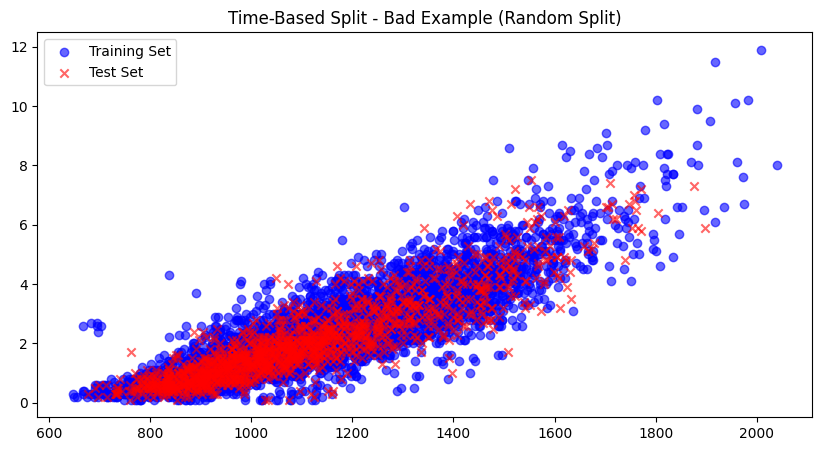

In [56]:
X_train, X_test, y_train, y_test = train_test_split(a[['PT08.S1(CO)']], a['CO(GT)'], test_size=0.2, random_state=42)

# Fit a simple model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
print(f"Time-Based Split - Bad Example Mean Squared Error (Random Split): {mse:.2f}")

# Plotting the data (scatter to show randomness)
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Training Set')
plt.scatter(X_test, y_test, color='red', alpha=0.6, marker='x', label='Test Set')
plt.title('Time-Based Split - Bad Example (Random Split)')
plt.legend()
plt.show()

In [57]:
# 9. TimeSeriesSplit
# Good Example: TimeSeriesSplit
X_air_quality = a[['PT08.S1(CO)', 'NO2(GT)', 'T', 'RH']]
y_air_quality = a['CO(GT)']

tscv = TimeSeriesSplit(n_splits=5)
model = LinearRegression()
mse_values = []

for train_index, test_index in tscv.split(X_air_quality):
    X_train, X_test = X_air_quality.iloc[train_index], X_air_quality.iloc[test_index]
    y_train, y_test = y_air_quality.iloc[train_index], y_air_quality.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)
    print(f"TimeSeriesSplit - Mean Squared Error: {mse:.2f}")

overall_mse = np.mean(mse_values)
print(f"Overall Mean Squared Error from TimeSeriesSplit: {overall_mse:.2f}")


TimeSeriesSplit - Mean Squared Error: 0.32
TimeSeriesSplit - Mean Squared Error: 0.31
TimeSeriesSplit - Mean Squared Error: 0.83
TimeSeriesSplit - Mean Squared Error: 0.60
TimeSeriesSplit - Mean Squared Error: 0.55
Overall Mean Squared Error from TimeSeriesSplit: 0.52


# Hierarchical split

In this more complex hierarchical split, we need to ensure that all data from the same school is either in the training or the test set. This means that if we put a school in the training set, all classrooms and students from that school must also be in the training set.

This hierarchical approach avoids leakage of school-level characteristics between training and testing.

In [62]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# Sample dataset
data = {
    'District_ID': ['D1', 'D1', 'D1', 'D1', 'D2', 'D3'],
    'School_ID': ['S1', 'S1', 'S1', 'S2', 'S3', 'S4'],
    'Grade': ['G1', 'G1', 'G2', 'G1', 'G3', 'G2'],
    'Classroom_ID': ['C1', 'C2', 'C3', 'C4', 'C5', 'C6'],
    'Student_ID': ['ST1', 'ST2', 'ST3', 'ST4', 'ST5', 'ST6'],
    'District_Funding': ['High', 'High', 'High', 'High', 'Medium', 'Low'],
    'School_Quality': ['Excellent', 'Excellent', 'Excellent', 'Good', 'Average', 'Poor'],
    'Teacher_Experience': ['12 Years', '8 Years', '10 Years', '7 Years', '5 Years', '3 Years'],
    'Student_Age': [10, 10, 11, 10, 12, 11],
    'Student_Gender': ['F', 'M', 'F', 'M', 'F', 'M'],
    'Exam_Score': [92, 88, 85, 80, 75, 60]
}

df = pd.DataFrame(data)
display('Original df:', df)

# Setting up the GroupShuffleSplit for cluster splitting
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

# Split based on the 'Store_ID' to ensure all customers from the same store are in the same split
for train_idx, test_idx in gss.split(df, groups=df['School_ID']):
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

# Displaying the results
print()
display("Training Set:", train_df)
print()
display("Testing Set:", test_df)


'Original df:'

,District_ID,School_ID,Grade,Classroom_ID,Student_ID,District_Funding,School_Quality,Teacher_Experience,Student_Age,Student_Gender,Exam_Score
0,D1,S1,G1,C1,ST1,High,Excellent,12 Years,10,F,92
1,D1,S1,G1,C2,ST2,High,Excellent,8 Years,10,M,88
2,D1,S1,G2,C3,ST3,High,Excellent,10 Years,11,F,85
3,D1,S2,G1,C4,ST4,High,Good,7 Years,10,M,80
4,D2,S3,G3,C5,ST5,Medium,Average,5 Years,12,F,75
5,D3,S4,G2,C6,ST6,Low,Poor,3 Years,11,M,60


'Training Set:'

,District_ID,School_ID,Grade,Classroom_ID,Student_ID,District_Funding,School_Quality,Teacher_Experience,Student_Age,Student_Gender,Exam_Score
0,D1,S1,G1,C1,ST1,High,Excellent,12 Years,10,F,92
1,D1,S1,G1,C2,ST2,High,Excellent,8 Years,10,M,88
2,D1,S1,G2,C3,ST3,High,Excellent,10 Years,11,F,85
4,D2,S3,G3,C5,ST5,Medium,Average,5 Years,12,F,75


'Testing Set:'

,District_ID,School_ID,Grade,Classroom_ID,Student_ID,District_Funding,School_Quality,Teacher_Experience,Student_Age,Student_Gender,Exam_Score
3,D1,S2,G1,C4,ST4,High,Good,7 Years,10,M,80
5,D3,S4,G2,C6,ST6,Low,Poor,3 Years,11,M,60


# KFold CV

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

target_name = 'Bankrupt?'
a = bancruptcy.copy()

# Create a dataset with imbalanced classes
X, y = a, a[target_name]
X = X.drop(columns=[target_name])

model = DecisionTreeClassifier()
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, zero_division=1),
    'recall': make_scorer(recall_score, zero_division=1),
    'f1': make_scorer(f1_score, zero_division=1)
}

# Perform cross-validation with multiple scoring metrics
cv_results = cross_validate(model, X, y, cv=kfold, scoring=scoring, verbose=2)

# Calculate and print average scores for each metric
print(f"Stratified Split - Acc: {cv_results['test_accuracy'].mean():.2f}, "
      f"Pr: {cv_results['test_precision'].mean():.2f}, "
      f"Rc: {cv_results['test_recall'].mean():.2f}, "
      f"f1: {cv_results['test_f1'].mean():.2f}")

[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.1s
[CV] END .................................................... total time=   2.4s
Stratified Split - Acc: 0.95, Pr: 0.34, Rc: 0.38, f1: 0.35


# Leave-One-Out Cross-Validation (LOOCV)

In [27]:
from sklearn.model_selection import LeaveOneOut

model = LogisticRegression(max_iter=200)
loo = LeaveOneOut()
cv_scores = cross_val_score(model, X_iris, y_iris, cv=loo)
print(f"Leave-One-Out Cross-Validation - Good Example Mean LOOCV Score: {cv_scores.mean():.2f}")

Leave-One-Out Cross-Validation - Good Example Mean LOOCV Score: 0.97


# Bias - Variance

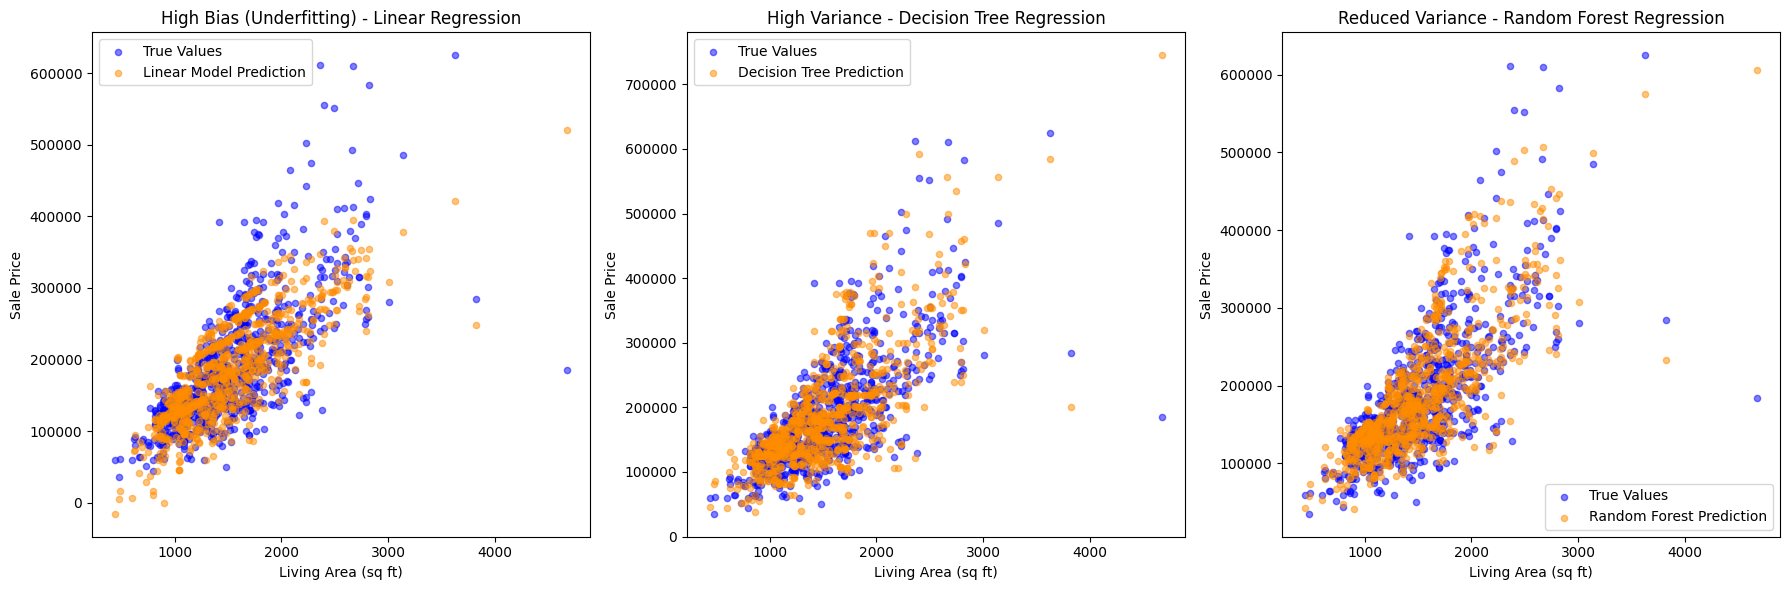

MSE 1435678911.5592144 , MAPE 0.1449504103433087 for Linear Regression: 
MSE 1703064673.788824 , MAPE 0.14671104799304513 for Decision Tree Regression: 
MSE 985088240.2512763 , MAPE 0.11314004336588605 for Random Forest Regression: 


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Load Ames Housing dataset
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Ames housing/') # replace with your path to the dataset!
fields_description_path = data_path/'data_description.txt'
dataset_path = data_path/'AmesHousing.csv'

# get fields description
with open(fields_description_path, 'r') as f:
    fields_description = f.read()

# get the dataset
df = pd.read_csv(dataset_path)
# Data Cleaning: Fill missing numeric values with zero for simplicity
df.fillna(0, inplace=True)

# Selecting features and the target
features = ['Gr Liv Area', 'Overall Qual', 'Year Built', 'Total Bsmt SF']
X = df[features].values
y = df['SalePrice'].values

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear regression model (High Bias)
linear_reg = LinearRegression()
linear_reg.fit(X_train_scaled, y_train)
y_pred_linear = linear_reg.predict(X_test_scaled)
mse_linear = mean_squared_error(y_test, y_pred_linear)
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear)

# Decision Tree regression model (High Variance)
dt_reg = DecisionTreeRegressor(max_depth=15, random_state=42)
dt_reg.fit(X_train, y_train)
y_pred_dt = dt_reg.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt)

# Random Forest regression model (Ensemble to reduce Variance)
rf_reg = RandomForestRegressor(n_estimators=50, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

# Plotting the Bias-Variance Tradeoff
plt.figure(figsize=(18, 6))

# Plot predictions for Linear Regression
plt.subplot(1, 3, 1)
plt.scatter(X_test[:, 0], y_test, s=20, alpha=0.5, color='blue', label='True Values')
plt.scatter(X_test[:, 0], y_pred_linear, s=20, alpha=0.5, color='darkorange', label='Linear Model Prediction')
plt.title('High Bias (Underfitting) - Linear Regression')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.legend()

# Plot predictions for Decision Tree Regression
plt.subplot(1, 3, 2)
plt.scatter(X_test[:, 0], y_test, s=20, alpha=0.5, color='blue', label='True Values')
plt.scatter(X_test[:, 0], y_pred_dt, s=20, alpha=0.5, color='darkorange', label='Decision Tree Prediction')
plt.title('High Variance - Decision Tree Regression')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.legend()

# Plot predictions for Random Forest Regression
plt.subplot(1, 3, 3)
plt.scatter(X_test[:, 0], y_test, s=20, alpha=0.5, color='blue', label='True Values')
plt.scatter(X_test[:, 0], y_pred_rf, s=20, alpha=0.5, color='darkorange', label='Random Forest Prediction')
plt.title('Reduced Variance - Random Forest Regression')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.legend()

plt.tight_layout()
plt.show()

print(f"MSE {mse_linear} , MAPE {mape_linear} for Linear Regression: ")
print(f"MSE {mse_dt} , MAPE {mape_dt} for Decision Tree Regression: ")
print(f"MSE {mse_rf} , MAPE {mape_rf} for Random Forest Regression: ")
